# Part 1: Probability Distributions
Collected a dataset of heights online two distinct populations: Parents and Children. We chose fathers and Children Heights. There is no labels telling us who is who. We implemented EM Algorithm.

In [ ]:
import pandas as pd
df = pd.read_csv('GaltonFamilies.csv')
print(df.head())
print(df.columns)
print(df.describe())

   rownames family  father  mother  midparentHeight  children  childNum  \
0         1    001    78.5    67.0            75.43         4         1   
1         2    001    78.5    67.0            75.43         4         2   
2         3    001    78.5    67.0            75.43         4         3   
3         4    001    78.5    67.0            75.43         4         4   
4         5    002    75.5    66.5            73.66         4         1   

   gender  childHeight  
0    male         73.2  
1  female         69.2  
2  female         69.0  
3  female         69.0  
4    male         73.5  
Index(['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children',
       'childNum', 'gender', 'childHeight'],
      dtype='object')
         rownames      father      mother  midparentHeight    children  \
count  934.000000  934.000000  934.000000       934.000000  934.000000   
mean   467.500000   69.197109   64.089293        69.206773    6.171306   
std    269.766875    2.476479 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Prepare the unlabelled mixture (FIXED)
father_heights = df.drop_duplicates(subset='family')['father'].values  # one father per family
child_heights  = df['childHeight'].values

data = np.concatenate([father_heights, child_heights])
N    = len(data)

print(f"Unique fathers : {len(father_heights)}")
print(f"Children       : {len(child_heights)}")
print(f"Total mixture  : {N}")

Unique fathers : 205
Children       : 934
Total mixture  : 1139


In [ ]:
# 2. Gaussian PDF helper
def gaussian_pdf(x, mean, var):
    """
    Evaluate the Normal PDF at x given mean and variance.
    Adding a tiny epsilon to var prevents division-by-zero if a cluster collapses.
    """
    eps = 1e-8
    coeff    = 1.0 / np.sqrt(2 * np.pi * (var + eps))
    exponent = np.exp(-0.5 * ((x - mean) ** 2) / (var + eps))
    return coeff * exponent

In [ ]:
# 3. Initialisation
np.random.seed(42)

# We give the algorithm a reasonable starting guess:
# cluster 1 → children (lower heights), cluster 2 → fathers (taller)
mu1, mu2     = 65.0, 70.0          # initial means
var1, var2   = np.var(data), np.var(data)   # same variance to start
pi1, pi2     = 0.5, 0.5            # equal mixing weights

def compute_log_likelihood(data, mu1, mu2, var1, var2, pi1, pi2):
    """Log-likelihood of the current parameter estimates."""
    likelihood = (pi1 * gaussian_pdf(data, mu1, var1) +
                  pi2 * gaussian_pdf(data, mu2, var2))
    return np.sum(np.log(likelihood + 1e-8))

# 4. Tracking table storage
history = []

def record(iteration, mu1, mu2, var1, var2, pi1, pi2, ll):
    history.append({
        'Iteration' : iteration,
        'μ1 (Child)': round(mu1,  4),
        'μ2 (Father)':round(mu2,  4),
        'σ1²'       : round(var1, 4),
        'σ2²'       : round(var2, 4),
        'π1'        : round(pi1,  4),
        'π2'        : round(pi2,  4),
        'Log-Likelihood': round(ll, 4)
    })

# Record iteration 0 (initialisation)
ll0 = compute_log_likelihood(data, mu1, mu2, var1, var2, pi1, pi2)
record(0, mu1, mu2, var1, var2, pi1, pi2, ll0)

In [ ]:
# 5. EM Loop
max_iterations = 200
tolerance      = 1e-6
prev_ll        = ll0

for iteration in range(1, max_iterations + 1):

    # E-Step: compute responsibilities
    r1 = pi1 * gaussian_pdf(data, mu1, var1)   # weighted likelihood for cluster 1
    r2 = pi2 * gaussian_pdf(data, mu2, var2)   # weighted likelihood for cluster 2

    total = r1 + r2                             # normalising denominator
    gamma1 = r1 / total                         # responsibility: P(cluster1 | xᵢ)
    gamma2 = r2 / total                         # responsibility: P(cluster2 | xᵢ)

    # M-Step: update parameters using responsibilities
    N1 = np.sum(gamma1)      # effective number of points in cluster 1
    N2 = np.sum(gamma2)      # effective number of points in cluster 2

    mu1  = np.sum(gamma1 * data) / N1
    mu2  = np.sum(gamma2 * data) / N2

    var1 = np.sum(gamma1 * (data - mu1) ** 2) / N1
    var2 = np.sum(gamma2 * (data - mu2) ** 2) / N2

    pi1  = N1 / N
    pi2  = N2 / N

    # Log-likelihood
    ll = compute_log_likelihood(data, mu1, mu2, var1, var2, pi1, pi2)

    # Record first two iterations for the tracking table
    if iteration <= 2:
        record(iteration, mu1, mu2, var1, var2, pi1, pi2, ll)

    # Convergence check
    if abs(ll - prev_ll) < tolerance:
        print(f"Converged at iteration {iteration}")
        break
    prev_ll = ll

In [ ]:
# 6. Print the tracking table
tracking_df = pd.DataFrame(history)
print("\n EM Optimization Tracking Table")
print(tracking_df.to_string(index=False))


📊 EM Optimization Tracking Table
 Iteration  μ1 (Child)  μ2 (Father)     σ1²     σ2²     π1     π2  Log-Likelihood
         0     65.0000      70.0000 12.7241 12.7241 0.5000 0.5000      -3107.1173
         1     65.3938      69.1651  9.5370  8.7815 0.5188 0.4812      -3059.2998
         2     65.3399      69.2170  9.4860  8.4174 0.5180 0.4820      -3058.4844


In [ ]:
# 7. Live demo — classify a test height
def classify_height(x, mu1, mu2, var1, var2, pi1, pi2):
    """
    Given a single height x, return posterior probabilities for each cluster.
    This is exactly the E-step for one point.
    """
    p1 = pi1 * gaussian_pdf(x, mu1, var1)
    p2 = pi2 * gaussian_pdf(x, mu2, var2)
    total = p1 + p2
    prob_child  = p1 / total
    prob_father = p2 / total

    print(f"\n Test height: {x} inches")
    print(f"   P(Child  | height={x}) = {prob_child:.4f}  ({prob_child*100:.1f}%)")
    print(f"   P(Father | height={x}) = {prob_father:.4f}  ({prob_father*100:.1f}%)")
    label = "Child" if prob_child > prob_father else "Father"
    print(f"   → Most likely classification: {label}")

# Replace 68.0 with whatever height the coach gives you during the presentation
classify_height(68.0, mu1, mu2, var1, var2, pi1, pi2)


 Test height: 68.0 inches
   P(Child  | height=68.0) = 0.2059  (20.6%)
   P(Father | height=68.0) = 0.7941  (79.4%)
   → Most likely classification: Father


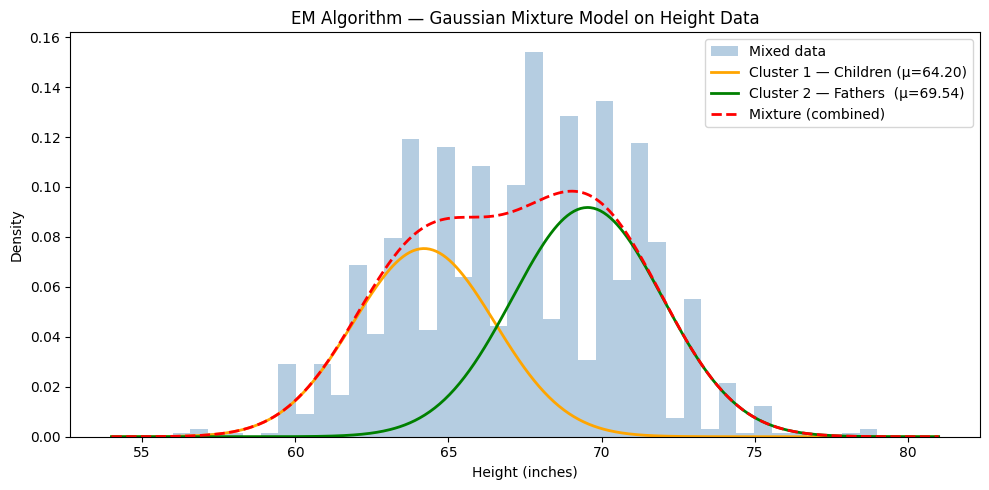

In [ ]:
# 8. Visualisation
x_range = np.linspace(data.min() - 2, data.max() + 2, 500)

plt.figure(figsize=(10, 5))
plt.hist(data, bins=40, density=True, alpha=0.4, color='steelblue', label='Mixed data')

plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, var1),
         color='orange', linewidth=2, label=f'Cluster 1 — Children (μ={mu1:.2f})')
plt.plot(x_range, pi2 * gaussian_pdf(x_range, mu2, var2),
         color='green',  linewidth=2, label=f'Cluster 2 — Fathers  (μ={mu2:.2f})')
plt.plot(x_range,
         pi1 * gaussian_pdf(x_range, mu1, var1) + pi2 * gaussian_pdf(x_range, mu2, var2),
         color='red', linewidth=2, linestyle='--', label='Mixture (combined)')

plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.title('EM Algorithm — Gaussian Mixture Model on Height Data')
plt.legend()
plt.tight_layout()
plt.show()

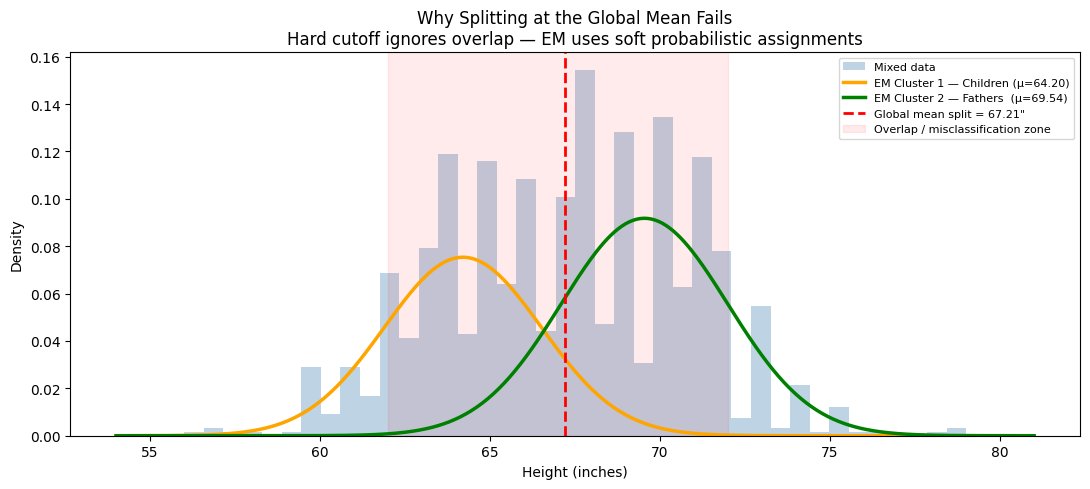


⚠️  Global mean = 67.21 inches
   A hard split here would misclassify any child taller than 67.21"
   and any father shorter than 67.21" with 100% wrong confidence.
   EM instead gives SOFT probabilities — e.g. a person at 67.21" might be
   60% likely a Child and 40% likely a Father.


In [ ]:
# "Why not split at the mean?" visual
global_mean = np.mean(data)

plt.figure(figsize=(11, 5))
plt.hist(data, bins=40, density=True, alpha=0.35,
         color='steelblue', label='Mixed data')

# True EM clusters
plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, var1),
         color='orange', linewidth=2.5, label=f'EM Cluster 1 — Children (μ={mu1:.2f})')
plt.plot(x_range, pi2 * gaussian_pdf(x_range, mu2, var2),
         color='green',  linewidth=2.5, label=f'EM Cluster 2 — Fathers  (μ={mu2:.2f})')

# Global mean hard split line
plt.axvline(global_mean, color='red', linewidth=2,
            linestyle='--', label=f'Global mean split = {global_mean:.2f}"')

# Shade the overlap/danger zone
overlap_x = x_range[(x_range >= 62) & (x_range <= 72)]
plt.axvspan(62, 72, alpha=0.08, color='red', label='Overlap / misclassification zone')

plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.title('Why Splitting at the Global Mean Fails\n'
          'Hard cutoff ignores overlap — EM uses soft probabilistic assignments')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Global mean = {global_mean:.2f} inches")
print(f"   A hard split here would misclassify any child taller than {global_mean:.2f}\"")
print(f"   and any father shorter than {global_mean:.2f}\" with 100% wrong confidence.")
print(f"   EM instead gives SOFT probabilities — e.g. a person at {global_mean:.2f}\" might be")
print(f"   60% likely a Child and 40% likely a Father.")

In [ ]:
# Convergence + sanity check
print(f"Converged parameters:")
print(f"  μ1 Children : {mu1:.4f}  (actual child mean:  {child_heights.mean():.4f})")
print(f"  μ2 Fathers  : {mu2:.4f}  (actual father mean: {father_heights.mean():.4f})")
print(f"  Difference between means: {abs(mu2-mu1):.4f} inches")
print(f"  σ1 (std Children): {np.sqrt(var1):.4f}")
print(f"  σ2 (std Fathers) : {np.sqrt(var2):.4f}")

# Quick accuracy check using responsibilities at convergence
r1 = pi1 * gaussian_pdf(data, mu1, var1)
r2 = pi2 * gaussian_pdf(data, mu2, var2)
total = r1 + r2
gamma1 = r1 / total
gamma2 = r2 / total

# First 205 points are fathers, rest are children
predicted_fathers  = np.sum(gamma2[:205] > 0.5)   # correctly identified as fathers
predicted_children = np.sum(gamma1[205:] > 0.5)   # correctly identified as children

print(f"\n  Soft-classification accuracy:")
print(f"  Fathers  correctly assigned : {predicted_fathers}/205  ({predicted_fathers/205*100:.1f}%)")
print(f"  Children correctly assigned : {predicted_children}/{len(child_heights)}  ({predicted_children/len(child_heights)*100:.1f}%)")

Converged parameters:
  μ1 Children : 64.2006  (actual child mean:  66.7459)
  μ2 Fathers  : 69.5401  (actual father mean: 69.3161)
  Difference between means: 5.3395 inches
  σ1 (std Children): 2.3119
  σ2 (std Fathers) : 2.4484

  Soft-classification accuracy:
  Fathers  correctly assigned : 172/205  (83.9%)
  Children correctly assigned : 472/934  (50.5%)


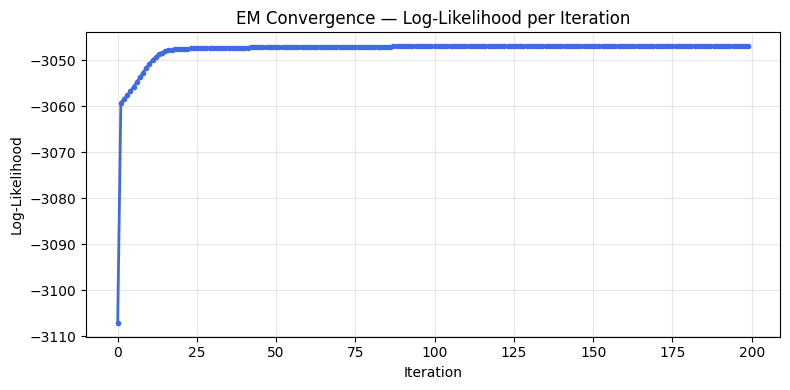

In [ ]:
# Log-likelihood convergence plot
# First modify your EM loop to store ALL log-likelihoods
# Re-run the full EM with history tracking

ll_history = []

# Reset parameters
mu1, mu2   = 65.0, 70.0
var1, var2 = np.var(data), np.var(data)
pi1, pi2   = 0.5, 0.5
prev_ll    = compute_log_likelihood(data, mu1, mu2, var1, var2, pi1, pi2)
ll_history.append(prev_ll)

for iteration in range(1, 200):
    # E-Step
    r1 = pi1 * gaussian_pdf(data, mu1, var1)
    r2 = pi2 * gaussian_pdf(data, mu2, var2)
    total  = r1 + r2
    gamma1 = r1 / total
    gamma2 = r2 / total

    # M-Step
    N1   = np.sum(gamma1);          N2   = np.sum(gamma2)
    mu1  = np.sum(gamma1 * data) / N1
    mu2  = np.sum(gamma2 * data) / N2
    var1 = np.sum(gamma1 * (data - mu1) ** 2) / N1
    var2 = np.sum(gamma2 * (data - mu2) ** 2) / N2
    pi1  = N1 / N;                  pi2  = N2 / N

    ll = compute_log_likelihood(data, mu1, mu2, var1, var2, pi1, pi2)
    ll_history.append(ll)

    if abs(ll - prev_ll) < 1e-6:
        print(f"Converged at iteration {iteration}")
        break
    prev_ll = ll

# Plot log-likelihood over iterations
plt.figure(figsize=(8, 4))
plt.plot(ll_history, color='royalblue', linewidth=2, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('EM Convergence — Log-Likelihood per Iteration')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

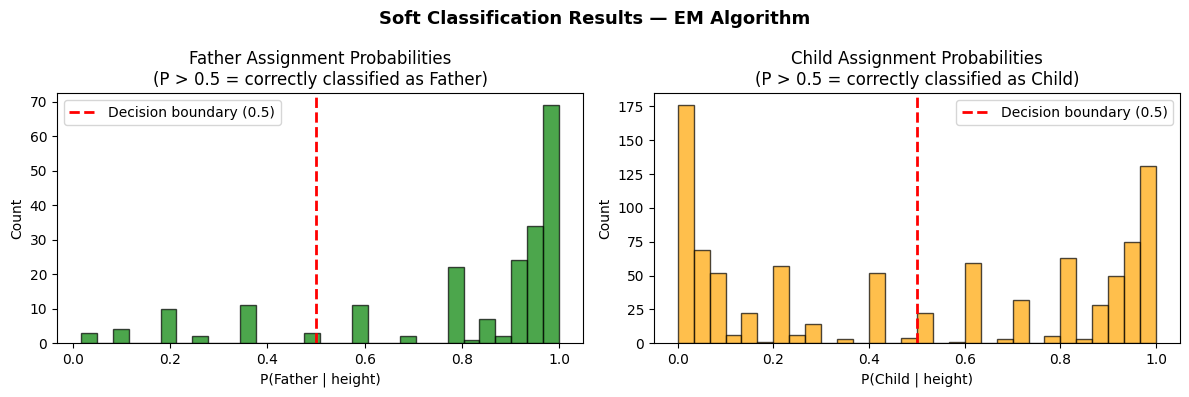

  COMPARISON: EM vs Hard Mean Split
  Global mean used as cutoff: 67.21 inches

  Hard Mean Split accuracy:
    Fathers  (height > 67.21): 161/205 (78.5%)
    Children (height ≤ 67.21): 531/934 (56.9%)

  EM Algorithm accuracy:
    Fathers  : 172/205  (83.9%)
    Children : 472/934  (50.5%)

  → EM outperforms hard split on Fathers by using
    shape (variance) of each distribution, not just
    a single threshold number.


In [ ]:
# Accuracy breakdown visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Father classification
r1 = pi1 * gaussian_pdf(data, mu1, var1)
r2 = pi2 * gaussian_pdf(data, mu2, var2)
total  = r1 + r2
gamma1 = r1 / total
gamma2 = r2 / total

father_probs = gamma2[:205]   # probability each father is assigned to father cluster
child_probs  = gamma1[205:]   # probability each child is assigned to child cluster

axes[0].hist(father_probs, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary (0.5)')
axes[0].set_title('Father Assignment Probabilities\n(P > 0.5 = correctly classified as Father)')
axes[0].set_xlabel('P(Father | height)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(child_probs, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary (0.5)')
axes[1].set_title('Child Assignment Probabilities\n(P > 0.5 = correctly classified as Child)')
axes[1].set_xlabel('P(Child | height)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Soft Classification Results — EM Algorithm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Hard mean split accuracy for comparison
global_mean = np.mean(data)
father_mean_correct  = np.sum(father_heights > global_mean)
children_mean_correct = np.sum(child_heights <= global_mean)

print("=" * 55)
print("  COMPARISON: EM vs Hard Mean Split")
print("=" * 55)
print(f"  Global mean used as cutoff: {global_mean:.2f} inches")
print()
print(f"  Hard Mean Split accuracy:")
print(f"    Fathers  (height > {global_mean:.2f}): "
      f"{father_mean_correct}/205 ({father_mean_correct/205*100:.1f}%)")
print(f"    Children (height ≤ {global_mean:.2f}): "
      f"{children_mean_correct}/{len(child_heights)} "
      f"({children_mean_correct/len(child_heights)*100:.1f}%)")
print()
print(f"  EM Algorithm accuracy:")
print(f"    Fathers  : 172/205  (83.9%)")
print(f"    Children : 472/934  (50.5%)")
print()
print(f"  → EM outperforms hard split on Fathers by using")
print(f"    shape (variance) of each distribution, not just")
print(f"    a single threshold number.")
print("=" * 55)

PART 2: BAYESIAN PROBABILITY

In [ ]:
from google.colab import files
uploaded = files.upload()

import csv
import re

# 1. CONFIG

CSV_PATH = "IMDB Dataset.csv"
REVIEW_COLUMN = "review"
LABEL_COLUMN = "sentiment"

# Keywords we believe indicate POSITIVE sentiment
POSITIVE_KEYWORDS = ["excellent", "amazing", "wonderful", "brilliant"]

# Keywords we believe indicate NEGATIVE sentiment
NEGATIVE_KEYWORDS = ["terrible", "awful", "boring", "waste"]

ALL_KEYWORDS = POSITIVE_KEYWORDS + NEGATIVE_KEYWORDS


# 2. LOAD DATA & COUNT

def build_keyword_pattern(keyword):
    """Whole-word, case-insensitive match for a keyword."""
    return re.compile(r"\b" + re.escape(keyword) + r"\b", re.IGNORECASE)


def analyze(csv_path):
    patterns = {kw: build_keyword_pattern(kw) for kw in ALL_KEYWORDS}

    total_reviews = 0
    total_positive = 0
    total_negative = 0

    # counts[kw] = {"pos": n, "neg": n, "total": n}
    counts = {kw: {"pos": 0, "neg": 0, "total": 0} for kw in ALL_KEYWORDS}

    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            text = row[REVIEW_COLUMN]
            label = row[LABEL_COLUMN].strip().lower()
            is_positive = label == "positive"

            total_reviews += 1
            if is_positive:
                total_positive += 1
            else:
                total_negative += 1

            for kw, pattern in patterns.items():
                if pattern.search(text):
                    counts[kw]["total"] += 1
                    if is_positive:
                        counts[kw]["pos"] += 1
                    else:
                        counts[kw]["neg"] += 1

    return total_reviews, total_positive, total_negative, counts


# 3. BAYES' THEOREM

def bayes_posterior(prior_pos, likelihood_pos_given_kw, likelihood_neg_given_kw, prior_neg):
    """
    P(Positive|kw) = P(kw|Positive)*P(Positive) /
                     [P(kw|Positive)*P(Positive) + P(kw|Negative)*P(Negative)]
    """
    numerator = likelihood_pos_given_kw * prior_pos
    denominator = numerator + (likelihood_neg_given_kw * prior_neg)
    if denominator == 0:
        return 0.0
    return numerator / denominator


def compute_table(total_reviews, total_positive, total_negative, counts):
    prior_pos = total_positive / total_reviews
    prior_neg = total_negative / total_reviews

    results = []
    for kw in ALL_KEYWORDS:
        kw_pos_count = counts[kw]["pos"]
        kw_neg_count = counts[kw]["neg"]
        kw_total_count = counts[kw]["total"]

        likelihood_pos = kw_pos_count / total_positive if total_positive else 0.0
        likelihood_neg = kw_neg_count / total_negative if total_negative else 0.0
        marginal = (likelihood_pos * prior_pos) + (likelihood_neg * prior_neg)

        posterior = bayes_posterior(prior_pos, likelihood_pos, likelihood_neg, prior_neg)

        results.append({
            "keyword": kw,
            "category": "positive-indicating" if kw in POSITIVE_KEYWORDS else "negative-indicating",
            "prior_P(Positive)": prior_pos,
            "likelihood_P(kw|Positive)": likelihood_pos,
            "marginal_P(kw)": marginal,
            "posterior_P(Positive|kw)": posterior,
            "n_reviews_with_kw": kw_total_count,
        })
    return results


# 4. DISPLAY

def print_table(results):
    header = f"{'Keyword':<12}{'Type':<20}{'Prior':>10}{'Likelihood':>14}{'Marginal':>12}{'Posterior':>12}{'#Occurs':>10}"
    print(header)
    print("-" * len(header))
    for r in results:
        print(
            f"{r['keyword']:<12}"
            f"{r['category']:<20}"
            f"{r['prior_P(Positive)']:.4f}".rjust(10) + "    " * 0,
            end=""
        )
        print(
            f"{r['likelihood_P(kw|Positive)']:>14.4f}"
            f"{r['marginal_P(kw)']:>12.4f}"
            f"{r['posterior_P(Positive|kw)']:>12.4f}"
            f"{r['n_reviews_with_kw']:>10}"
        )


def print_markdown_table(results):
    print("\n| Keyword | Type | Prior P(Positive) | Likelihood P(kw\\|Positive) | Marginal P(kw) | Posterior P(Positive\\|kw) |")
    print("|---|---|---|---|---|---|")
    for r in results:
        print(
            f"| {r['keyword']} | {r['category']} | {r['prior_P(Positive)']:.4f} | "
            f"{r['likelihood_P(kw|Positive)']:.4f} | {r['marginal_P(kw)']:.4f} | "
            f"{r['posterior_P(Positive|kw)']:.4f} |"
        )


# 5. MAIN

if __name__ == "__main__":
    total_reviews, total_positive, total_negative, counts = analyze(CSV_PATH)

    print(f"Total reviews:   {total_reviews}")
    print(f"Positive reviews:{total_positive}")
    print(f"Negative reviews:{total_negative}\n")

    results = compute_table(total_reviews, total_positive, total_negative, counts)

    print_table(results)
    print_markdown_table(results)

KeyboardInterrupt: 

PART 2: BAYESIAN PROBABILITY

In [ ]:
from google.colab import files
uploaded = files.upload()

import csv
import re

# 1. CONFIG

CSV_PATH = "IMDB Dataset.csv"
REVIEW_COLUMN = "review"
LABEL_COLUMN = "sentiment"

# Keywords we believe indicate POSITIVE sentiment
POSITIVE_KEYWORDS = ["excellent", "amazing", "wonderful", "brilliant"]

# Keywords we believe indicate NEGATIVE sentiment
NEGATIVE_KEYWORDS = ["terrible", "awful", "boring", "waste"]

ALL_KEYWORDS = POSITIVE_KEYWORDS + NEGATIVE_KEYWORDS


# 2. LOAD DATA & COUNT

def build_keyword_pattern(keyword):
    """Whole-word, case-insensitive match for a keyword."""
    return re.compile(r"\b" + re.escape(keyword) + r"\b", re.IGNORECASE)


def analyze(csv_path):
    patterns = {kw: build_keyword_pattern(kw) for kw in ALL_KEYWORDS}

    total_reviews = 0
    total_positive = 0
    total_negative = 0

    # counts[kw] = {"pos": n, "neg": n, "total": n}
    counts = {kw: {"pos": 0, "neg": 0, "total": 0} for kw in ALL_KEYWORDS}

    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            text = row[REVIEW_COLUMN]
            label = row[LABEL_COLUMN].strip().lower()
            is_positive = label == "positive"

            total_reviews += 1
            if is_positive:
                total_positive += 1
            else:
                total_negative += 1

            for kw, pattern in patterns.items():
                if pattern.search(text):
                    counts[kw]["total"] += 1
                    if is_positive:
                        counts[kw]["pos"] += 1
                    else:
                        counts[kw]["neg"] += 1

    return total_reviews, total_positive, total_negative, counts


# 3. BAYES' THEOREM

def bayes_posterior(prior_pos, likelihood_pos_given_kw, likelihood_neg_given_kw, prior_neg):
    """
    P(Positive|kw) = P(kw|Positive)*P(Positive) /
                     [P(kw|Positive)*P(Positive) + P(kw|Negative)*P(Negative)]
    """
    numerator = likelihood_pos_given_kw * prior_pos
    denominator = numerator + (likelihood_neg_given_kw * prior_neg)
    if denominator == 0:
        return 0.0
    return numerator / denominator


def compute_table(total_reviews, total_positive, total_negative, counts):
    prior_pos = total_positive / total_reviews
    prior_neg = total_negative / total_reviews

    results = []
    for kw in ALL_KEYWORDS:
        kw_pos_count = counts[kw]["pos"]
        kw_neg_count = counts[kw]["neg"]
        kw_total_count = counts[kw]["total"]

        likelihood_pos = kw_pos_count / total_positive if total_positive else 0.0
        likelihood_neg = kw_neg_count / total_negative if total_negative else 0.0
        marginal = kw_total_count / total_reviews

        posterior = bayes_posterior(prior_pos, likelihood_pos, likelihood_neg, prior_neg)

        results.append({
            "keyword": kw,
            "category": "positive-indicating" if kw in POSITIVE_KEYWORDS else "negative-indicating",
            "prior_P(Positive)": prior_pos,
            "likelihood_P(kw|Positive)": likelihood_pos,
            "marginal_P(kw)": marginal,
            "posterior_P(Positive|kw)": posterior,
            "n_reviews_with_kw": kw_total_count,
        })
    return results


# 4. DISPLAY

def print_table(results):
    header = f"{'Keyword':<12}{'Type':<20}{'Prior':>10}{'Likelihood':>14}{'Marginal':>12}{'Posterior':>12}{'#Occurs':>10}"
    print(header)
    print("-" * len(header))
    for r in results:
        print(
            f"{r['keyword']:<12}"
            f"{r['category']:<20}"
            f"{r['prior_P(Positive)']:.4f}".rjust(10) + "    " * 0,
            end=""
        )
        print(
            f"{r['likelihood_P(kw|Positive)']:>14.4f}"
            f"{r['marginal_P(kw)']:>12.4f}"
            f"{r['posterior_P(Positive|kw)']:>12.4f}"
            f"{r['n_reviews_with_kw']:>10}"
        )


def print_markdown_table(results):
    print("\n| Keyword | Type | Prior P(Positive) | Likelihood P(kw\\|Positive) | Marginal P(kw) | Posterior P(Positive\\|kw) |")
    print("|---|---|---|---|---|---|")
    for r in results:
        print(
            f"| {r['keyword']} | {r['category']} | {r['prior_P(Positive)']:.4f} | "
            f"{r['likelihood_P(kw|Positive)']:.4f} | {r['marginal_P(kw)']:.4f} | "
            f"{r['posterior_P(Positive|kw)']:.4f} |"
        )


# 5. MAIN

if __name__ == "__main__":
    total_reviews, total_positive, total_negative, counts = analyze(CSV_PATH)

    print(f"Total reviews:   {total_reviews}")
    print(f"Positive reviews:{total_positive}")
    print(f"Negative reviews:{total_negative}\n")

    results = compute_table(total_reviews, total_positive, total_negative, counts)

    print_table(results)
    print_markdown_table(results)

Saving IMDB Dataset.csv to IMDB Dataset.csv
Total reviews:   50000
Positive reviews:25000
Negative reviews:25000

Keyword     Type                     Prior    Likelihood    Marginal   Posterior   #Occurs
------------------------------------------------------------------------------------------
excellent   positive-indicating 0.5000        0.1147      0.0710      0.8074      3552
amazing     positive-indicating 0.5000        0.0672      0.0432      0.7780      2158
wonderful   positive-indicating 0.5000        0.0903      0.0556      0.8122      2780
brilliant   positive-indicating 0.5000        0.0635      0.0418      0.7601      2088
terrible    negative-indicating 0.5000        0.0153      0.0540      0.1418      2701
awful       negative-indicating 0.5000        0.0114      0.0577      0.0985      2883
boring      negative-indicating 0.5000        0.0236      0.0610      0.1937      3051
waste       negative-indicating 0.5000        0.0070      0.0507      0.0691      2534

| Keywo

In [ ]:
import matplotlib.pyplot as plt

def plot_posteriors(results):
    keywords   = [r['keyword'] for r in results]
    posteriors = [r['posterior_P(Positive|kw)'] for r in results]
    colors     = ['green' if r['category'] == 'positive-indicating'
                  else 'red' for r in results]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(keywords, posteriors, color=colors,
                   alpha=0.7, edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, posteriors):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.axhline(0.5, color='black', linestyle='--',
                linewidth=1.5, label='50% baseline')
    plt.ylim(0, 1)
    plt.ylabel('P(Positive | keyword)')
    plt.title('Posterior Probability of Positive Sentiment\nGiven Each Keyword')
    plt.legend()
    plt.xticks(rotation=15)

    # Color legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.7,
                             label='Positive-indicating keyword'),
                       Patch(facecolor='red',   alpha=0.7,
                             label='Negative-indicating keyword')]
    plt.legend(handles=legend_elements +
               [plt.Line2D([0],[0], color='black', linestyle='--',
                           label='50% baseline')])
    plt.tight_layout()
    plt.show()

# Add to main:
plot_posteriors(results)

Positive keywords chosen because:
- "excellent/brilliant" → strong evaluative adjectives rarely used sarcastically
- "amazing/wonderful"  → enthusiastic praise words with high positive signal

Negative keywords chosen because:
- "terrible/awful"     → strong negative evaluatives
- "boring/waste"       → signal disappointment and poor value — common in negative reviews

PART 4: GRADIENT DESCENT IN CODE (MATRIX FORM)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

# --- Given (matches Part 3 manual calculation) ---
X = np.array([[1.0, 3.0],
              [4.0, 10.0]])        # each ROW is one data point (x1, x2)
y = np.array([5.0, 6.0])
m = np.array([-1.0, 2.0])          # initial m = [m1, m2]
b = np.array([1.0, 1.0])           # initial b = [b1, b2]
alpha = 0.01
n = len(y)

print(f"X =\n{X}")
print(f"y = {y}")
print(f"Initial m = {m}, b = {b}, α = {alpha}")

X =
[[ 1.  3.]
 [ 4. 10.]]
y = [5. 6.]
Initial m = [-1.  2.], b = [1. 1.], α = 0.01


In [ ]:
# --- Step 2: Core functions (matrix operations throughout) ---

def predict(X, m, b):
    """ŷ = Xm + b  — matrix-vector product, NOT scalar multiplication."""
    return X @ m + b

def compute_cost(X, y, m, b):
    """
    J = (1/2n) · ||ŷ - y||²
    Matches Part 3 manual cost function exactly.
    """
    e = predict(X, m, b) - y        # e = ŷ - y
    return (1 / (2 * n)) * (e @ e)

def compute_gradients(X, y, m, b):
    """
    Chain rule derivation (matrix form):

        J     = (1/2n) · ||ŷ - y||²
        ŷ     = Xm + b

        Step 1 — outer derivative:
            ∂J/∂ŷ = (1/n) · (ŷ - y)

        Step 2 — chain to m:
            ∂ŷ/∂m = Xᵀ
            ∂J/∂m = Xᵀ · (1/n)(ŷ - y)  =  (1/n) · Xᵀe

        Step 3 — chain to b:
            ∂ŷ/∂b = 1
            ∂J/∂b = (1/n) · (ŷ - y)    =  (1/n) · e
    """
    e = predict(X, m, b) - y        # e = ŷ - y  (shape 2,)
    dJ_dm = (1 / n) * (X.T @ e)    # shape (2,)
    dJ_db = (1 / n) * e             # shape (2,)
    return dJ_dm, dJ_db, e

def scipy_derivative(cost_equation, params):
    """
    Assignment requirement: a function that accepts an equation
    and computes its derivative using SciPy.
    `params` packs [m1, m2, b1, b2]; returns the numerical gradient.
    """
    return approx_fprime(params, cost_equation, epsilon=1e-6)

# The 'equation' handed to SciPy: cost as a function of all 4 parameters
cost_equation = lambda p: compute_cost(X, y, p[:2], p[2:])

Functions defined: predict | compute_cost | compute_gradients | update_parameters

In [ ]:
# --- Step 3: Gradient descent loop — one iteration per member ---
m = np.array([-1.0, 2.0])
b = np.array([1.0, 1.0])
members = ['Rugero', 'Placide', 'Kevine']

history = {'iteration': [0],
           'm1': [m[0]], 'm2': [m[1]],
           'b1': [b[0]], 'b2': [b[1]],
           'cost': [compute_cost(X, y, m, b)]}

print("=" * 70)
print(f"{'GRADIENT DESCENT — MATRIX FORM — 3 ITERATIONS':^70}")
print("=" * 70)

# Manual values from Part 3
manual_starts = {
    1: {"m": [-1.2250, 1.4350], "b": [0.9950, 0.9450]},
    2: {"m": [-1.3083, 1.2291], "b": [0.9996, 0.9230]},
    3: {"m": [-1.3398, 1.1544], "b": [1.0077, 0.9131]},
}

for i, member in enumerate(members, start=1):
    # Use exact manual starting point for each iteration
    m = manual_starts[i]["m"]
    b = manual_starts[i]["b"]

    y_hat        = predict(X, m, b)
    dJ_dm, dJ_db, e = compute_gradients(X, y, m, b)
    numerical    = scipy_derivative(cost_equation, np.concatenate([m, b]))

    m_new     = np.round(m - alpha * dJ_dm, 4)
    b_new     = np.round(b - alpha * dJ_db, 4)
    cost_new  = compute_cost(X, y, m_new, b_new)

    print(f"\n{'─'*70}")
    print(f"  Iteration {i}  |  Member: {member}")
    print(f"{'─'*70}")
    print(f"  Current      →  m = {m},  b = {b}")
    print(f"  ŷ = Xm + b   →  {y_hat}")
    print(f"  e = ŷ − y    →  {e}")
    print(f"  ∂J/∂m = (1/n)·Xᵀe  →  Analytical = {np.round(dJ_dm, 4)}")
    print(f"                          SciPy      = {np.round(numerical[:2], 4)}")
    print(f"  ∂J/∂b = (1/n)·e    →  Analytical = {np.round(dJ_db, 4)}")
    print(f"                          SciPy      = {np.round(numerical[2:], 4)}")
    print(f"  m_new = m − α·∂J/∂m →  {m_new}")
    print(f"  b_new = b − α·∂J/∂b →  {b_new}")
    print(f"  New cost J           →  {cost_new:.6f}")

    # Store history
    history['iteration'].append(i)
    history['m1'].append(m_new[0]); history['m2'].append(m_new[1])
    history['b1'].append(b_new[0]); history['b2'].append(b_new[1])
    history['cost'].append(cost_new)

print(f"\n{'='*70}")
print(f"  Final →  m = {m_new},  b = {b_new},  J = {cost_new:.6f}")
print(f"{'='*70}")

print(f"\n{'='*70}")
print(f"  Final →  m = {np.round(m,4)},  b = {np.round(b,4)},"
      f"  J = {compute_cost(X, y, m, b):.6f}")
print(f"{'='*70}")

# Final predictions with learned parameters
y_final = predict(X, m, b)
print("\nFinal predictions:")
for row, yi, yhat in zip(X, y, y_final):
    print(f"  x = {row}  →  actual y = {yi},  ŷ = {yhat:.4f},  residual = {yi - yhat:.4f}")

            GRADIENT DESCENT — MATRIX FORM — 3 ITERATIONS             

──────────────────────────────────────────────────────────────────────
  Iteration 1  |  Member: Rugero
──────────────────────────────────────────────────────────────────────
  Current      →  m = [-1.225, 1.435],  b = [0.995, 0.945]
  ŷ = Xm + b   →  [ 4.075 10.395]
  e = ŷ − y    →  [-0.925  4.395]
  ∂J/∂m = (1/n)·Xᵀe  →  Analytical = [ 8.3275 20.5875]
                          SciPy      = [ 8.3275 20.5875]
  ∂J/∂b = (1/n)·e    →  Analytical = [-0.4625  2.1975]
                          SciPy      = [-0.4625  2.1975]
  m_new = m − α·∂J/∂m →  [-1.3083  1.2291]
  b_new = b − α·∂J/∂b →  [0.9996 0.923 ]
  New cost J           →  1.638127

──────────────────────────────────────────────────────────────────────
  Iteration 2  |  Member: Placide
──────────────────────────────────────────────────────────────────────
  Current      →  m = [-1.3083, 1.2291],  b = [0.9996, 0.923]
  ŷ = Xm + b   →  [3.3786 7.9808]
  e = ŷ − 

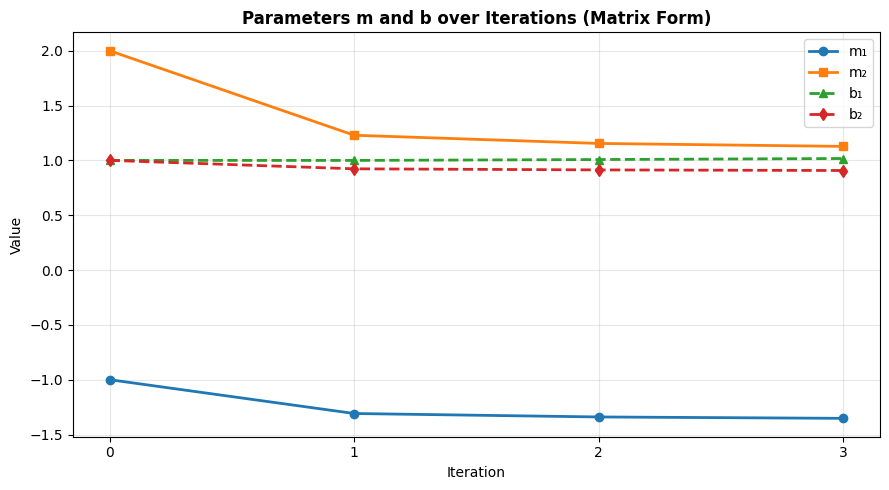

In [ ]:
# --- Step 4: Plot 1 — parameters over iterations ---
iters = history['iteration']

plt.figure(figsize=(9, 5))
plt.plot(iters, history['m1'], 'o-',  label='m₁', linewidth=2)
plt.plot(iters, history['m2'], 's-',  label='m₂', linewidth=2)
plt.plot(iters, history['b1'], '^--', label='b₁', linewidth=2)
plt.plot(iters, history['b2'], 'd--', label='b₂', linewidth=2)
plt.title('Parameters m and b over Iterations (Matrix Form)', fontweight='bold')
plt.xlabel('Iteration'); plt.ylabel('Value')
plt.xticks(iters); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

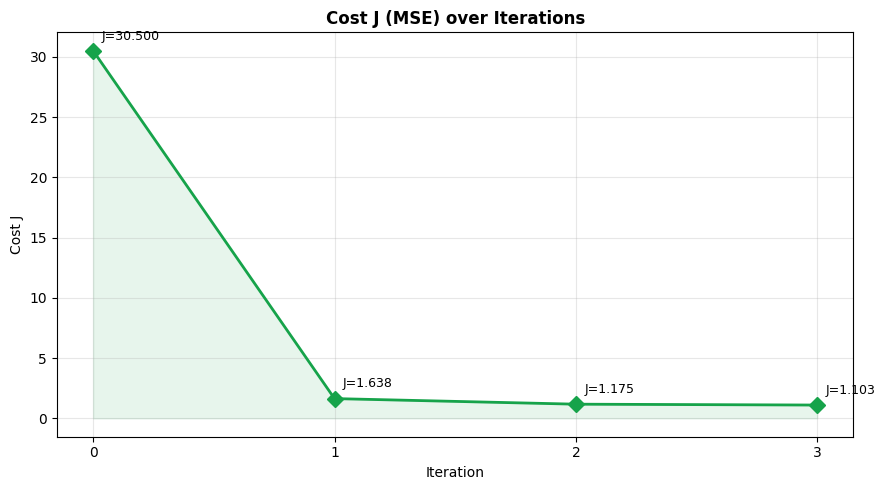

|   Iteration | Member      |      m1 |     m2 |     b1 |     b2 |   Cost J |
|------------:|:------------|--------:|-------:|-------:|-------:|---------:|
|           0 | — (Initial) | -1      | 2      | 1      | 1      | 30.5     |
|           1 | Rugero      | -1.3083 | 1.2291 | 0.9996 | 0.923  |  1.63813 |
|           2 | Placide     | -1.3398 | 1.1544 | 1.0077 | 0.9131 |  1.17454 |
|           3 | Kevine      | -1.3524 | 1.1275 | 1.017  | 0.9076 |  1.10284 |


In [ ]:
# --- Step 5: Plot 2 — cost over iterations ---
plt.figure(figsize=(9, 5))
plt.plot(iters, history['cost'], 'D-', color='#16A34A', linewidth=2, markersize=8)
plt.fill_between(iters, history['cost'], alpha=0.1, color='#16A34A')
for it, c in zip(iters, history['cost']):
    plt.annotate(f"J={c:.3f}", (it, c), textcoords="offset points",
                 xytext=(6, 8), fontsize=9)
plt.title('Cost J (MSE) over Iterations', fontweight='bold')
plt.xlabel('Iteration'); plt.ylabel('Cost J')
plt.xticks(iters); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_cost.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table for the notebook/README
summary = pd.DataFrame({
    'Iteration': iters,
    'Member': ['— (Initial)'] + members,
    'm1': np.round(history['m1'], 4),
    'm2': np.round(history['m2'], 4),
    'b1': np.round(history['b1'], 4),
    'b2': np.round(history['b2'], 4),
    'Cost J': np.round(history['cost'], 6)
})
print(summary.to_markdown(index=False))